# 0. COMPLEX QUERIES 

## Problems & Solutions : 

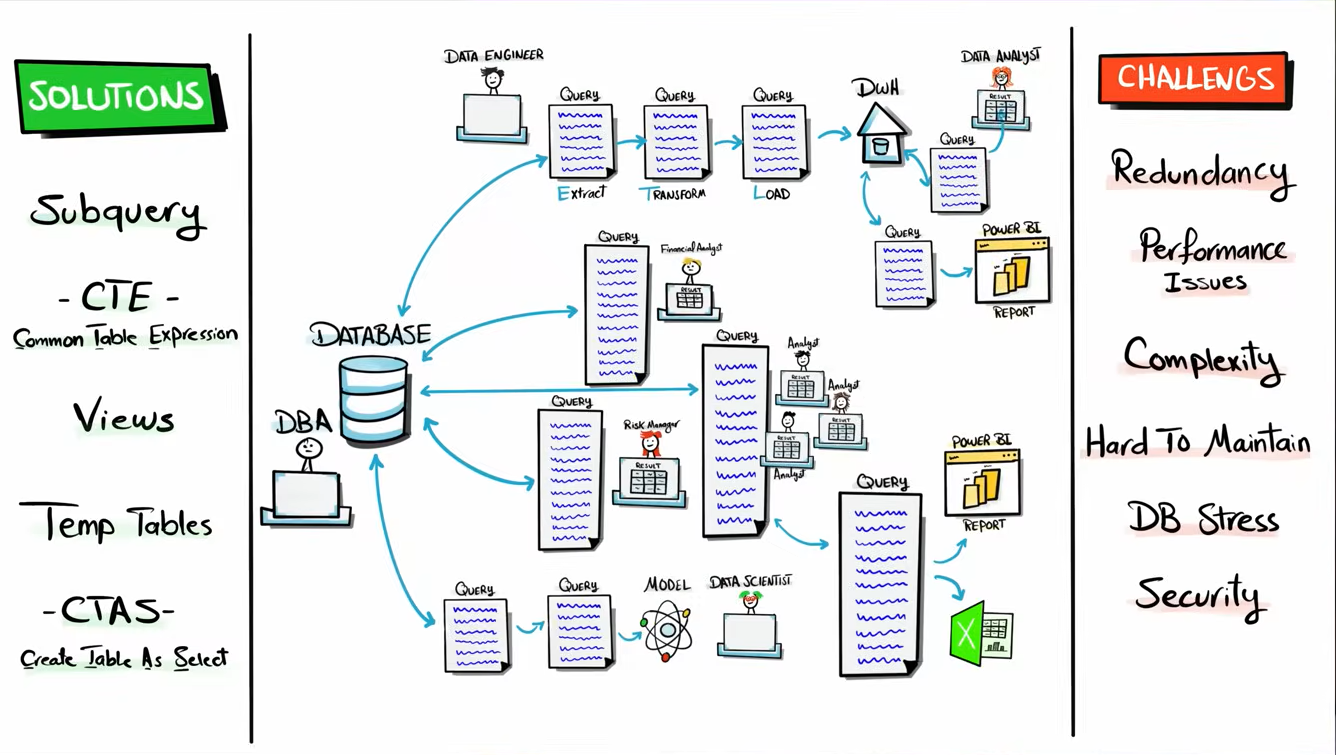

## DataBase Architecture : 

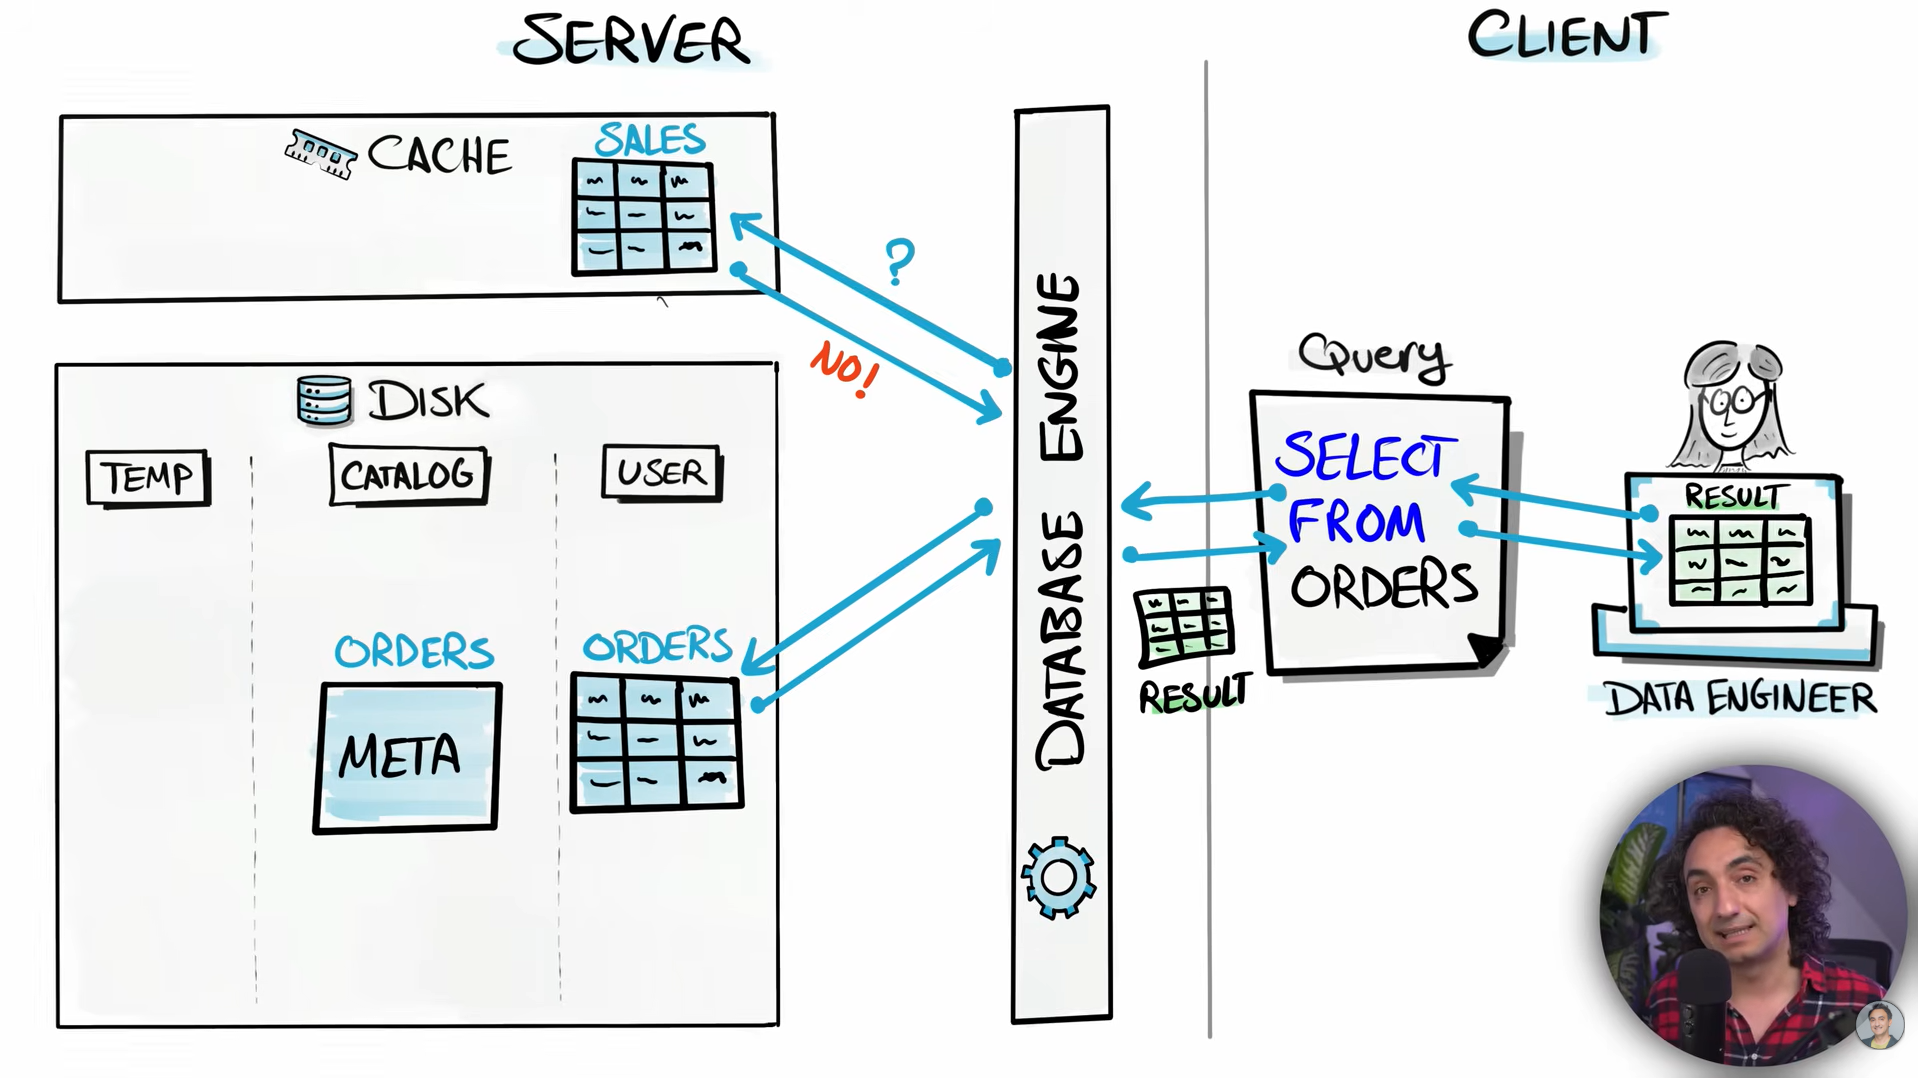

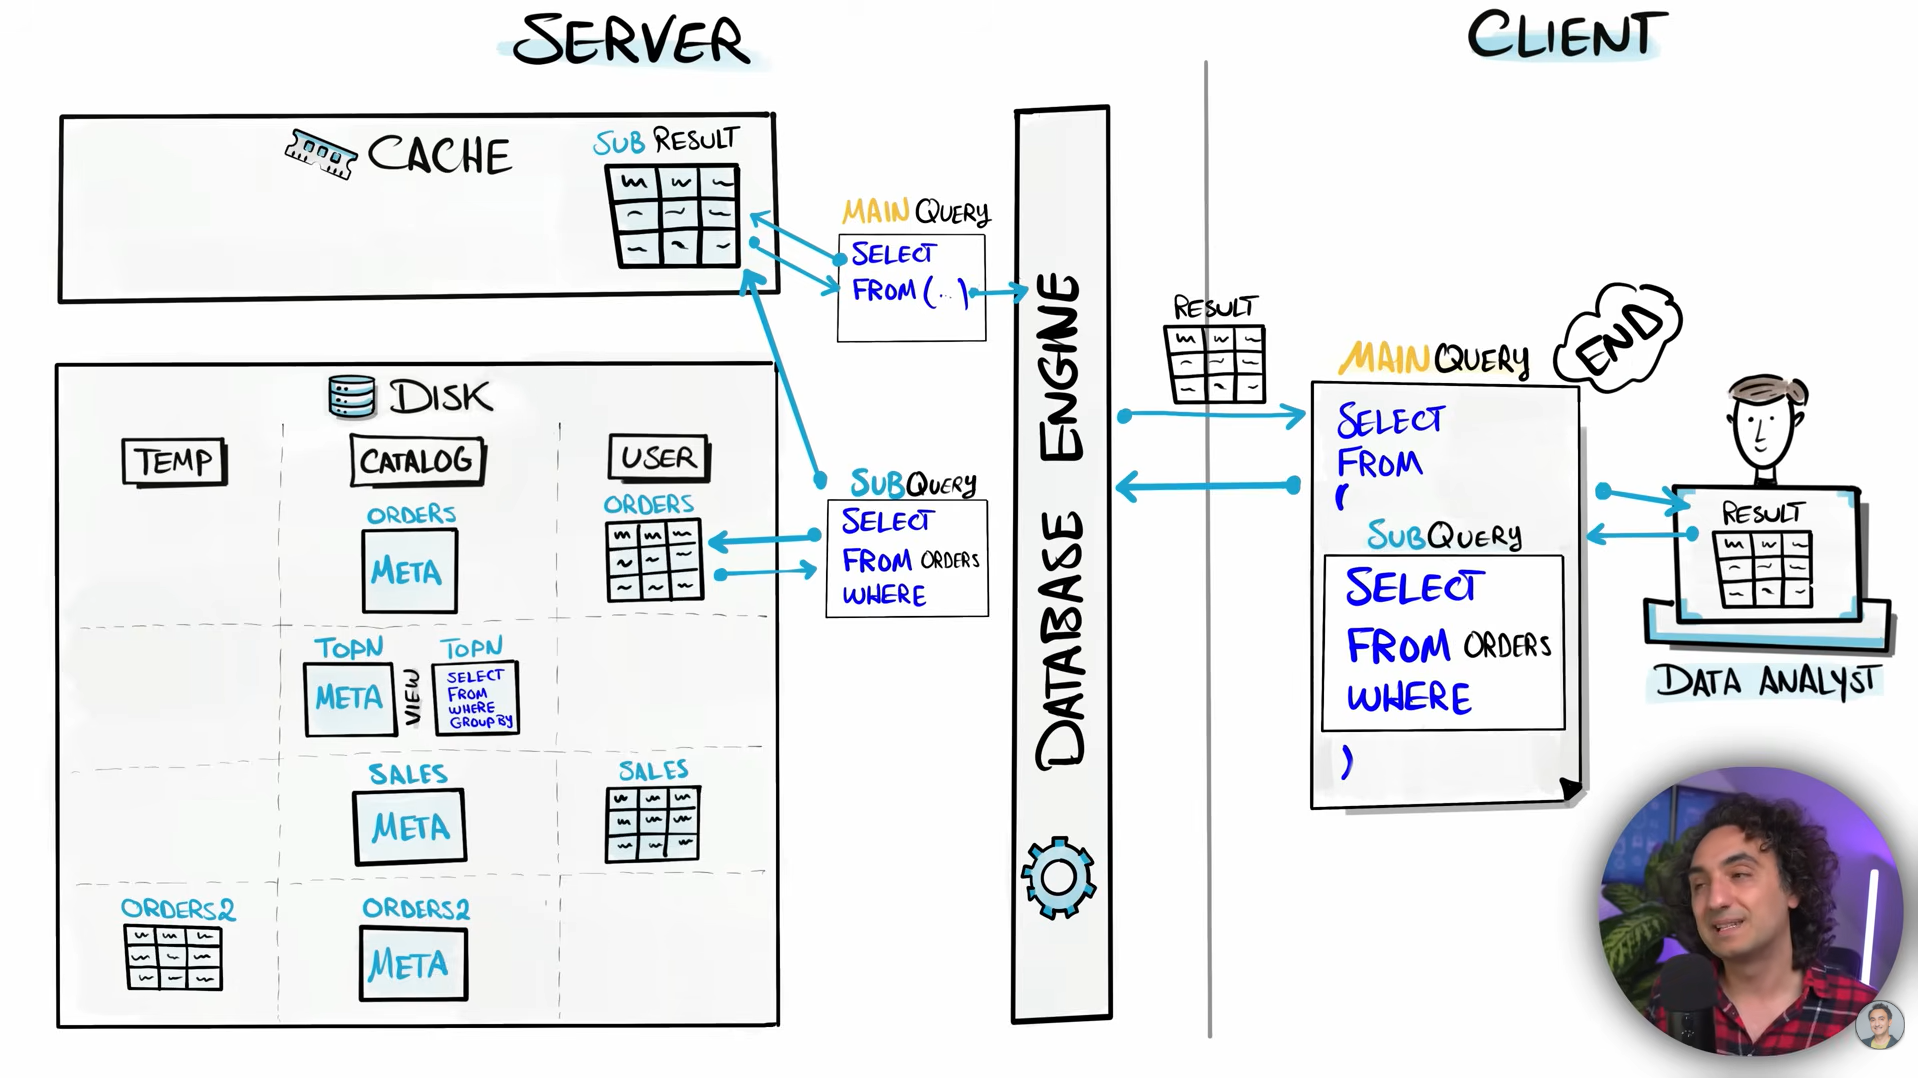

## Definitions : 

### DWH : Dataware House

```
Dataware house is a special database that collect and integrates data from different sources to enable analytics and support decision making.
```

### DataBase Engine : 

```
It is the brain of database, executing multiple operations such as storing, retrieving, and managing data within the database.
```

### Disk Storage :

```
Long term memory, where data is stored permanently

Advantage : 
    1. Capacity : Can hold a large amount of data

Disadvantages : 
    2. Speed : Slow to read and to write
```

### Cache Storage :

```
Fast short-term memory, where the data is stored temporarily.

Advantage :
    1. Speed : Extremely fast to read and to write

Disadvantage :
    1. Capacity : Can hold smaller amount of data
```

### User Data Storage : 

```
It's the main content of the Database.
This is where the actual data that users care about is stored.
```

### System Catalog : 

```
Database's internal storage for its own information.
A blueprint that keeps track of everything about the database itself, not the user data.

Main Purpose of System Catalog:
    . It Holds the METADATA information about the databases.
```

### Metadata : 

```
Data about Data
```

### Information Schema : 

```
A system defined schema with built-in views that provide info about the database, like tables and columns
```

In [22]:
%%sql
select * from information_schema.columns where column_name = 'sales';

Running query in 'mysql+pymysql://'

3 rows affected.

TABLE_CATALOG,TABLE_SCHEMA,TABLE_NAME,COLUMN_NAME,ORDINAL_POSITION,COLUMN_DEFAULT,IS_NULLABLE,DATA_TYPE,CHARACTER_MAXIMUM_LENGTH,CHARACTER_OCTET_LENGTH,NUMERIC_PRECISION,NUMERIC_SCALE,DATETIME_PRECISION,CHARACTER_SET_NAME,COLLATION_NAME,COLUMN_TYPE,COLUMN_KEY,EXTRA,PRIVILEGES,COLUMN_COMMENT,GENERATION_EXPRESSION,SRS_ID
def,MyDatabase,orders,sales,4,None,YES,int,None,None,10,0,None,None,None,int,,,"select,insert,update,references",,,None
def,salesdb,orders,sales,11,None,YES,int,None,None,10,0,None,None,None,int,,,"select,insert,update,references",,,None
def,salesdb,orders_archive,sales,12,None,YES,int,None,None,10,0,None,None,None,int,,,"select,insert,update,references",,,None


### Temp Data Storage : 

```
Temporary space used by the database for short-term tasks, like processing queries or sorting data.
Once these tasks are done, the storage get auto cleared.
```

# 1. SUBQUERIES

## Intro : 

```
A Query inside Another Query
```

### Visual : 

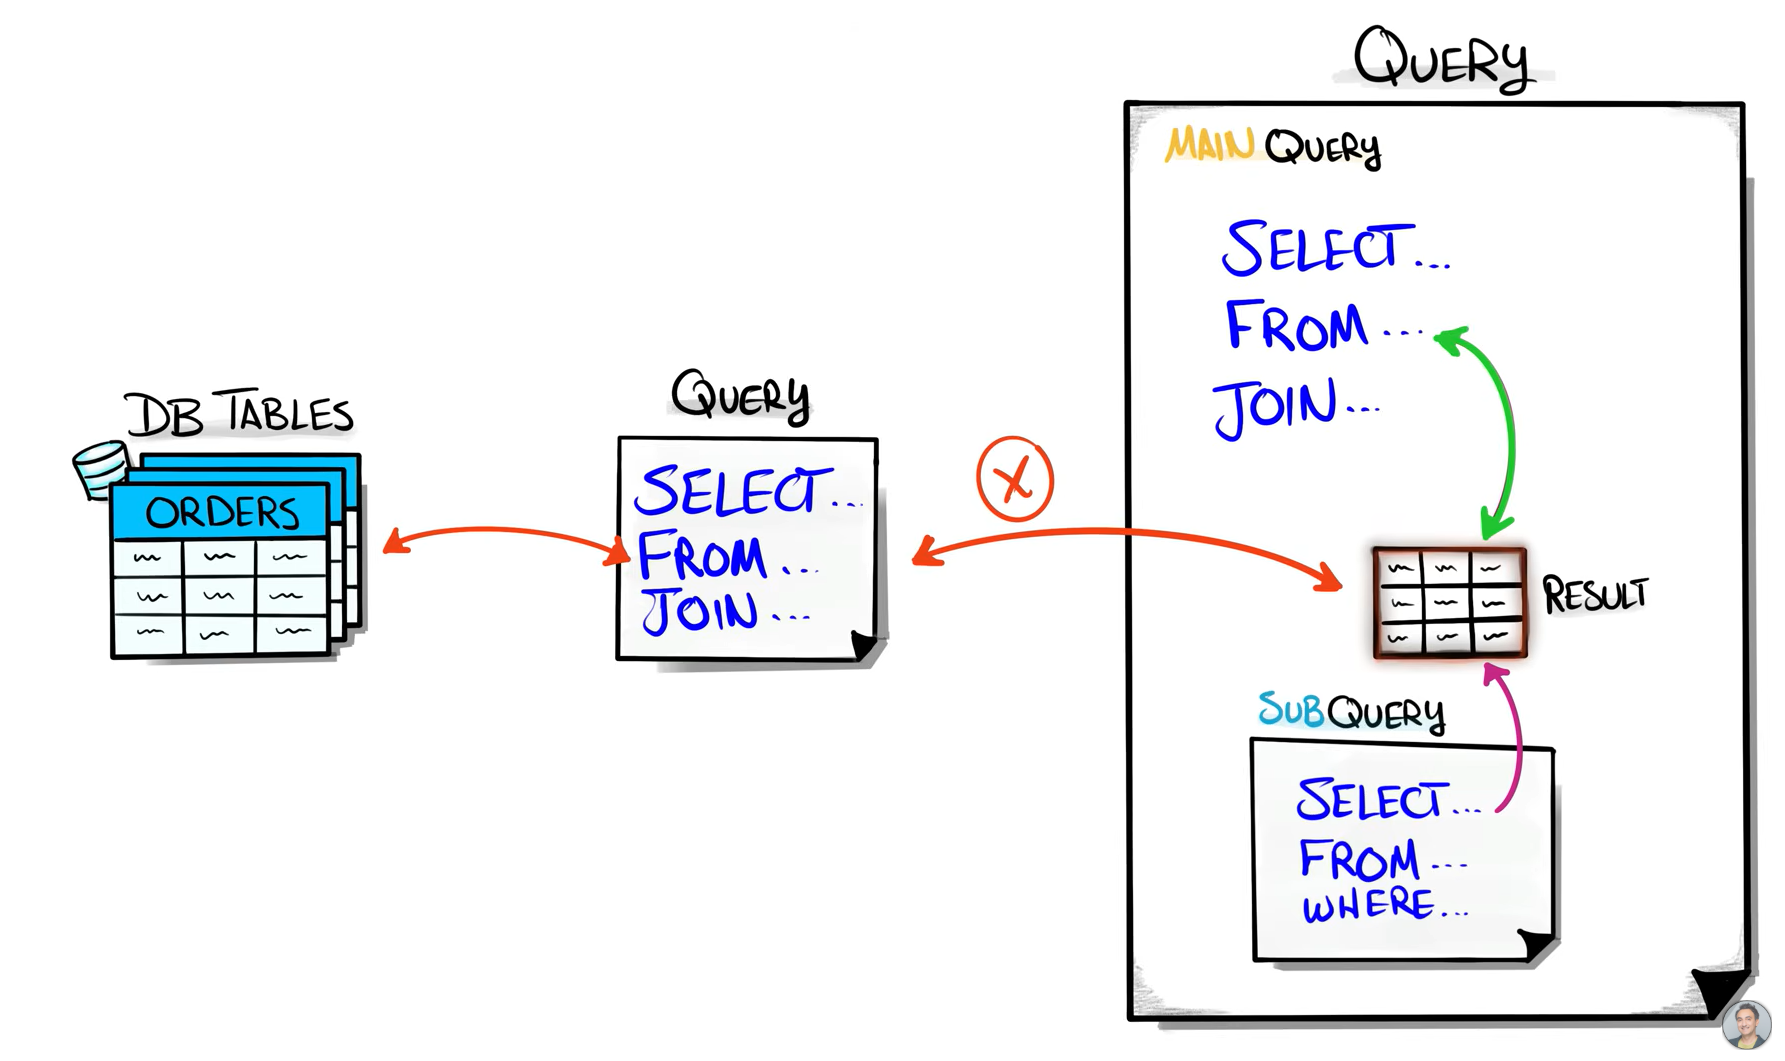

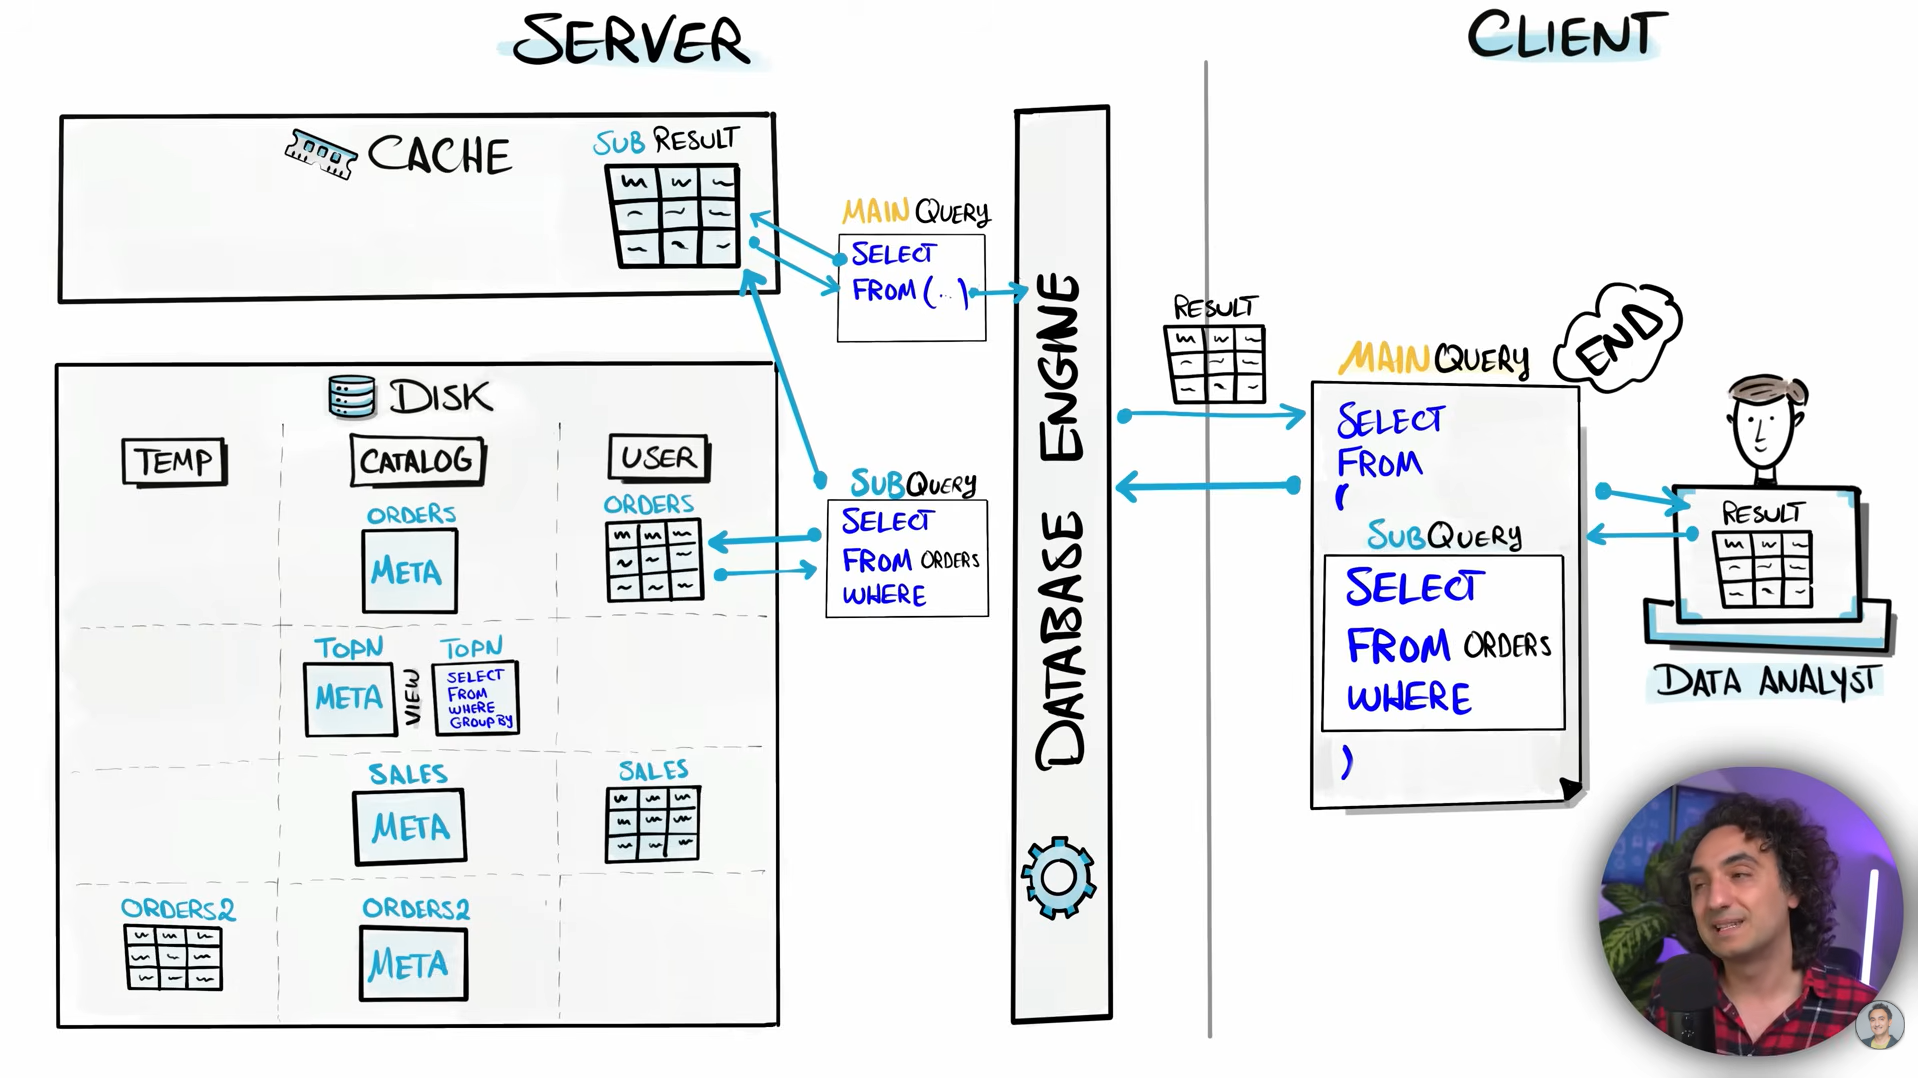

### Why SubQueries?

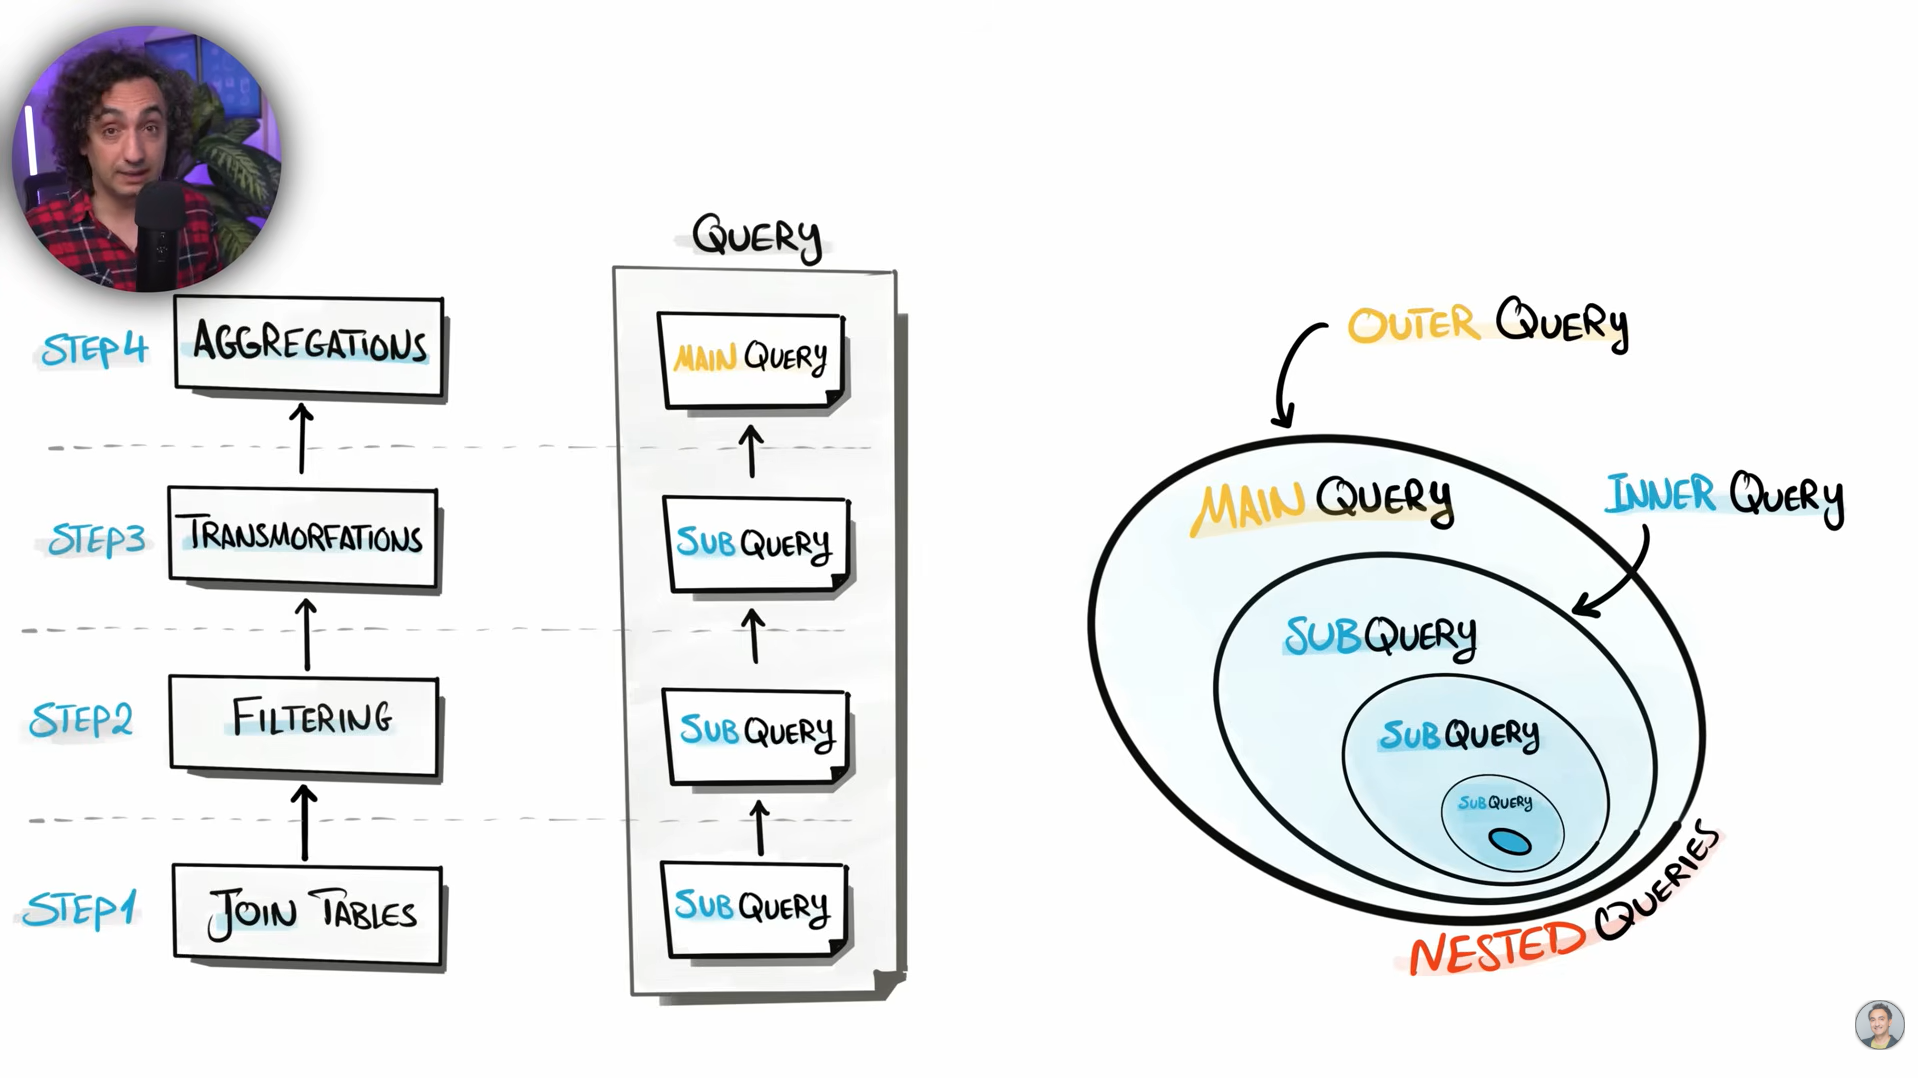

## Types : 

### Types Presentation : 

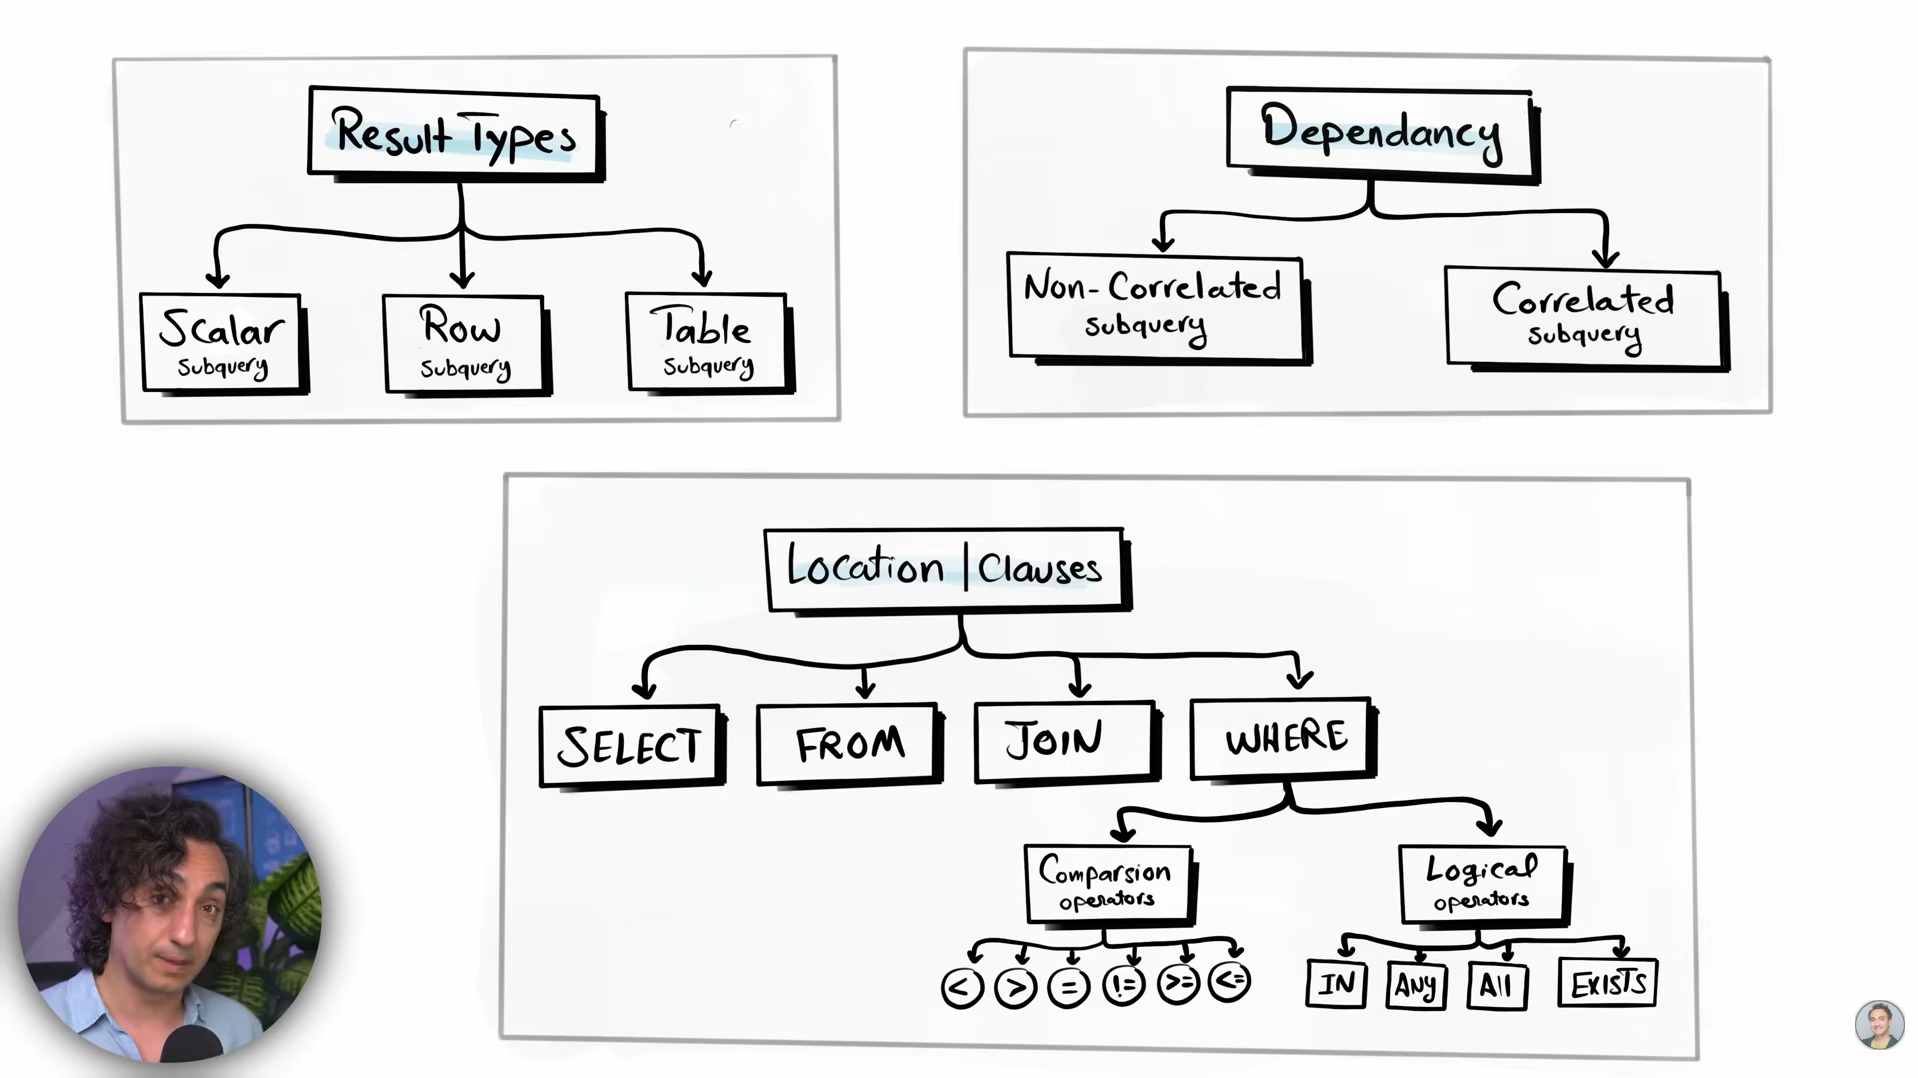

### 1. Result Types Sub-Queries : (Scalar, Row, Table)

#### Types : 

##### Scalar SubQueries : Return SINGLE VALUE output

```Ex: AVG, Total, Count, etc...```

##### Row SubQueries : Returns multiple row but single column records

```Ex: ID, Name, AGE, etc...```

##### Table SubQueries : Returns multiple rows and multiple column records from table

```Ex: All Records, Combination of Name, Age, etc..```

##### Visual Representation : 

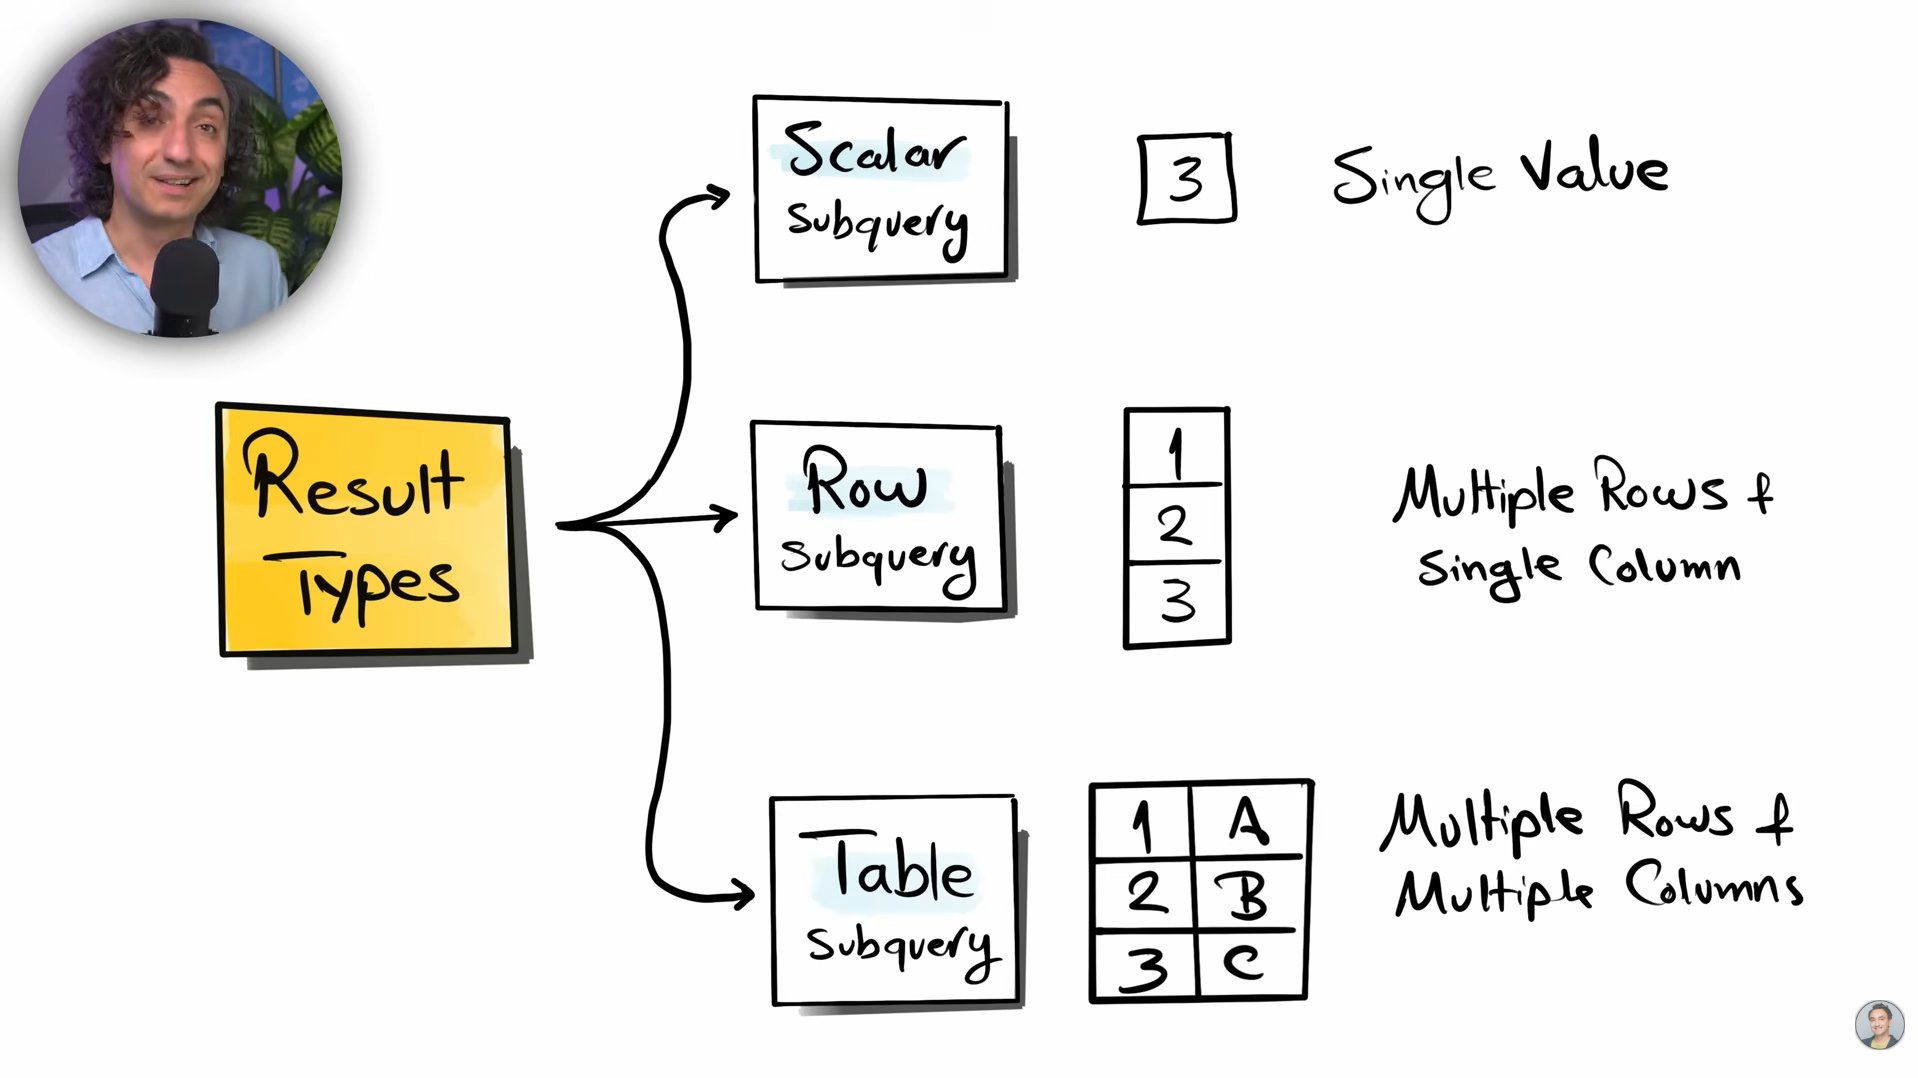

#### Challenges : 

##### Scalar : 

Find out the total number of records in orders.

In [24]:
%%sql
select count(*) as Total_Records
from orders;

Running query in 'mysql+pymysql://'

1 rows affected.

Total_Records
10


Find out the average sales of all orders.

In [31]:
%%sql
select round(coalesce(avg(sales), 0), 1) as `AVG_Sales`
from orders;

Running query in 'mysql+pymysql://'

1 rows affected.

AVG_Sales
38.0


##### Row : 

Find out the order id of each orders

In [32]:
%%sql
select orderid from orders;

Running query in 'mysql+pymysql://'

10 rows affected.

orderid
1
3
8
9
2
7
10
5
6
4


Find out the product id from orders table

In [33]:
%%sql
select distinct productid from orders order by productid;

Running query in 'mysql+pymysql://'

4 rows affected.

productid
101
102
104
105


Find out the Cutomer id from orders table

In [34]:
%%sql
select distinct customerid from orders order by customerid;

Running query in 'mysql+pymysql://'

4 rows affected.

customerid
1
2
3
4


##### Table :

Find out the orderid and customerid from orders.

In [35]:
%%sql
select orderid, customerid from orders;

Running query in 'mysql+pymysql://'

10 rows affected.

orderid,customerid
3,1
4,1
7,1
1,2
5,2
9,2
2,3
6,3
10,3
8,4


Find out the all records from orders.

In [36]:
%%sql
select * from orders;

Running query in 'mysql+pymysql://'

10 rows affected.

orderid,productid,customerid,salespersonid,orderdate,shipdate,orderstatus,shipaddress,billaddress,quantity,sales,creationtime
1,101,2,3,2025-01-01,2025-01-05,Delivered,9833 Mt. Dias Blv.,1226 Shoe St.,1,10,2025-01-01 12:34:56
2,102,3,3,2025-01-05,2025-01-10,Shipped,250 Race Court,None,1,15,2025-01-05 23:22:04
3,101,1,5,2025-01-10,2025-01-25,Delivered,8157 W. Book,8157 W. Book,2,20,2025-01-10 18:24:08
4,105,1,3,2025-01-20,2025-01-25,Shipped,5724 Victory Lane,,2,60,2025-01-20 05:50:33
5,104,2,5,2025-02-01,2025-02-05,Delivered,None,None,1,25,2025-02-01 14:02:41
6,104,3,5,2025-02-05,2025-02-10,Delivered,1792 Belmont Rd.,None,2,50,2025-02-06 15:34:57
7,102,1,1,2025-02-15,2025-02-27,Delivered,136 Balboa Court,,2,30,2025-02-16 06:22:01
8,101,4,3,2025-02-18,2025-02-27,Shipped,2947 Vine Lane,4311 Clay Rd,3,90,2025-02-18 10:45:22
9,101,2,3,2025-03-10,2025-03-15,Shipped,3768 Door Way,,2,20,2025-03-10 12:59:04
10,102,3,5,2025-03-15,2025-03-20,Shipped,None,None,0,60,2025-03-16 23:25:15


### 2. Dependancy Types Sub-Queries : (Non-Correlated, Correlated)

### 3. Location / Clause Types Sub-Queries : 
### (SELECT, FROM, JOIN, WHERE([COMPARISION - (<,>,=,!=,>=,<=)], [LOGICAL - (IN, ANY, ALL, EXISTS)]))

#### Types : 

##### 1. SELECT SubQuery : Used to aggregate data side by side with the main query's data, allowing for direct comparision.

```
Syntax : 

SELECT col1,
    col2,
    (select newCol1 from table2 where condition) as alias
from table1;

NOTE : in select the subquery only accept the scalar output subquery
```

Show the product ids, names, price, and total number of orders.

In [71]:
%%sql
select productid, product, category, price,
(select count(*) as `TotalOrders` from orders) as `Total Orders`
from products;

Running query in 'mysql+pymysql://'

5 rows affected.

productid,product,category,price,Total Orders
101,Bottle,Accessories,10,10
102,Tire,Accessories,15,10
103,Socks,Clothing,20,10
104,Caps,Clothing,25,10
105,Gloves,Clothing,30,10


##### 2. FROM SubQuery : Used as temporary table for the main query 

```
Syntax : 

SELECT col1, col2, col3, .. FROM (SELECT * FROM table1 WHERE condition) as alias
                                 -----------SUB - QUERY --------------
----------------------------------------MAIN QUERY--------------------------------
```

Find the products that have a price higher than the average price of all products

In [46]:
%%sql
select *
from(
        select *,
            round(avg(coalesce(price, 0)) OVER(), 1) as `AVG_Price`
        from products
    ) t
where price > AVG_Price;

Running query in 'mysql+pymysql://'

2 rows affected.

productid,product,category,price,AVG_Price
104,Caps,Clothing,25,20.0
105,Gloves,Clothing,30,20.0


Rank the customers based on their total amout of sales

In [61]:
%%sql
select *,
    RANK() OVER(
        ORDER BY Total_Sales DESC
    ) as Ranks
from(
        select o.customerid,
            concat_ws(' ', c.firstname, c.lastname) as `Customers`,
            sum(o.sales) as `Total_Sales`
        from orders as o
            left join customers as c on o.customerid = c.customerid
        group by o.customerid
    ) t;

Running query in 'mysql+pymysql://'

4 rows affected.

customerid,Customers,Total_Sales,Ranks
3,Mary,125,1
1,Jossef Goldberg,110,2
4,Mark Schwarz,90,3
2,Kevin Brown,55,4


## USECASES : 

## SUMMARY : 

# 2. CTE

## Intro : 

## Types : 

## USECASES : 

## SUMMARY : 

# 3. VIEWS

## Intro : 

## Types : 

## USECASES : 

## SUMMARY : 

# 4. CTAS TABLE & TEMP TABLES

## Intro : 

## Types : 

## USECASES : 

## SUMMARY : 

# 5. STORED PROCEDURE

## Intro : 

## Types : 

## USECASES : 

## SUMMARY : 

# 6. TRIGGERS

## Intro : 

## Types : 

## USECASES : 

## SUMMARY : 

# Extra :

In [8]:
%%sql
use salesdb;

Running query in 'mysql+pymysql://'

++
||
++
++

In [1]:
%%sql
show databases;

Running query in 'mysql+pymysql://'

7 rows affected.

Database
MyDatabase
defaultdb
information_schema
mysql
performance_schema
salesdb
sys
